In [4]:
%pip install pandas
import pandas as pd
df = pd.read_csv("fake_job_postings.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'fake_job_postings.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [ ]:
df.describe

<bound method NDFrame.describe of        job_id                                              title  \
0           1                                   Marketing Intern   
1           2          Customer Service - Cloud Video Production   
2           3            Commissioning Machinery Assistant (CMA)   
3           4                  Account Executive - Washington DC   
4           5                                Bill Review Manager   
...       ...                                                ...   
17875   17876                   Account Director - Distribution    
17876   17877                                 Payroll Accountant   
17877   17878  Project Cost Control Staff Engineer - Cost Con...   
17878   17879                                   Graphic Designer   
17879   17880                         Web Application Developers   

                   location   department salary_range  \
0          US, NY, New York    Marketing          NaN   
1            NZ, , Auckland      Su

In [ ]:
df.shape

(17880, 18)

In [ ]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

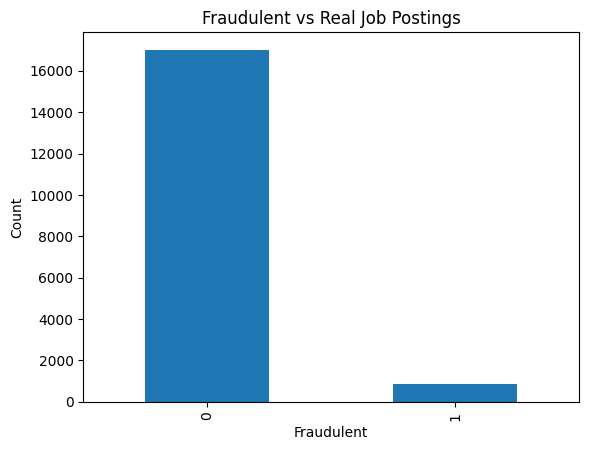

In [ ]:
import matplotlib.pyplot as plt

df['fraudulent'].value_counts().plot(kind='bar')
plt.title("Fraudulent vs Real Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Count")
plt.show()


In [ ]:
df = df.drop(columns=['job_id'])

In [ ]:
df['description'].str.len().describe()

count    17879.000000
mean      1218.072543
std        894.807276
min          6.000000
25%        607.000000
50%       1017.000000
75%       1586.000000
max      14907.000000
Name: description, dtype: float64

In [ ]:
df.isnull().mean().sort_values(ascending=False)

salary_range           0.839597
department             0.645805
required_education     0.453300
benefits               0.403356
required_experience    0.394295
function               0.361018
industry               0.274217
employment_type        0.194128
company_profile        0.185011
requirements           0.150783
location               0.019351
description            0.000056
title                  0.000000
telecommuting          0.000000
has_questions          0.000000
has_company_logo       0.000000
fraudulent             0.000000
dtype: float64

In [ ]:
df = df.drop(columns=['salary_range', 'department'])
df.shape

(17880, 15)

In [ ]:
df['employment_type'].value_counts(dropna=False).head(10)

employment_type
Full-time    11620
NaN           3471
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

In [ ]:
df.groupby('fraudulent')[['has_company_logo', 'telecommuting', 'has_questions']].mean()

,has_company_logo,telecommuting,has_questions
fraudulent,,,
0,0.819149,0.041319,0.502057
1,0.326790,0.073903,0.288684


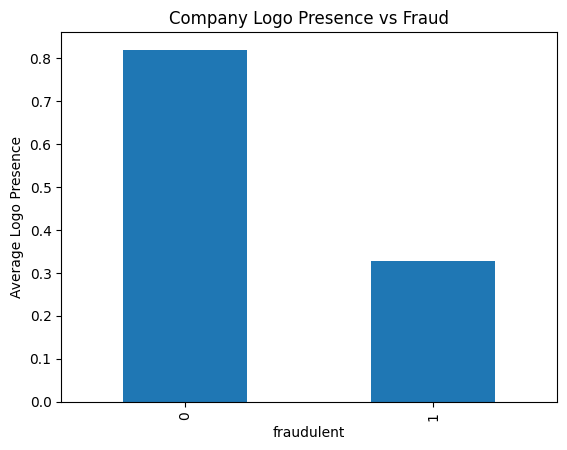

In [ ]:
df.groupby('fraudulent')['has_company_logo'].mean().plot(kind='bar')
plt.title("Company Logo Presence vs Fraud")
plt.ylabel("Average Logo Presence")
plt.show()

In [ ]:
df = df.drop(columns=['location'])

In [ ]:
df[['description', 'requirements', 'company_profile']].isnull().mean()

description        0.000056
requirements       0.150783
company_profile    0.185011
dtype: float64

In [ ]:
text_cols = ['description', 'requirements', 'company_profile', 'benefits', 'title']
df[text_cols] = df[text_cols].fillna("")

In [ ]:
df['desc_len'] = df['description'].str.len()
df['req_len'] = df['requirements'].str.len()
df['profile_len'] = df['company_profile'].str.len()
df['benefits_len'] = df['benefits'].str.len()

df[['desc_len', 'req_len', 'profile_len', 'benefits_len']].describe()

,desc_len,req_len,profile_len,benefits_len
count,17880.000000,17880.000000,17880.000000,17880.000000
mean,1218.004418,590.132215,620.901454,208.895694
std,894.828620,613.191270,567.454100,337.077357
min,0.000000,0.000000,0.000000,0.000000
25%,607.000000,146.000000,138.000000,0.000000
50%,1017.000000,467.000000,570.000000,45.000000
75%,1586.000000,820.000000,879.000000,294.000000
max,14907.000000,10864.000000,6178.000000,4429.000000


In [ ]:
text_cols = ['title', 'description', 'requirements', 'company_profile', 'benefits']
cat_cols = ['employment_type', 'required_experience', 'required_education', 'industry', 'function']
num_cols = [
    'has_company_logo',
    'has_questions',
    'telecommuting',
    'desc_len',
    'req_len',
    'profile_len',
    'benefits_len'
]
print("Text cols",text_cols)
print("Cat cols",cat_cols)
print("Num cols",num_cols)


Text cols ['title', 'description', 'requirements', 'company_profile', 'benefits']
Cat cols ['employment_type', 'required_experience', 'required_education', 'industry', 'function']
Num cols ['has_company_logo', 'has_questions', 'telecommuting', 'desc_len', 'req_len', 'profile_len', 'benefits_len']


In [ ]:
df[text_cols] = df[text_cols].fillna("")

In [ ]:
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [ ]:
from sklearn.model_selection import train_test_split

X = df[text_cols + cat_cols + num_cols]
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape


((14304, 17), (3576, 17))

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

text_feature = 'description'

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english', max_features=5000), text_feature),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('numeric', 'passthrough', num_cols)
    ]
)

model = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=200))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


c:\Users\FAZIL K FAAZI\Desktop\Aesthetix\Machine learning\general_env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.99      0.84      0.91      3403
           1       0.21      0.82      0.33       173

    accuracy                           0.84      3576
   macro avg       0.60      0.83      0.62      3576
weighted avg       0.95      0.84      0.88      3576



In [ ]:
df['text_all'] = (
    df['title'] + " " +
    df['description'] + " " +
    df['requirements'] + " " +
    df['company_profile'] + " " +
    df['benefits']
)

X = df[['text_all'] + cat_cols + num_cols]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((14304, 13), (3576, 13))

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english', max_features=10000), 'text_all'),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('numeric', 'passthrough', num_cols)
    ]
)

In [ ]:
model = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=200))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

c:\Users\FAZIL K FAAZI\Desktop\Aesthetix\Machine learning\general_env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.99      0.86      0.92      3403
           1       0.24      0.86      0.37       173

    accuracy                           0.86      3576
   macro avg       0.62      0.86      0.65      3576
weighted avg       0.96      0.86      0.90      3576



In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

model_svm = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LinearSVC(class_weight='balanced'))
])

model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.79      0.87      0.83       173

    accuracy                           0.98      3576
   macro avg       0.89      0.93      0.91      3576
weighted avg       0.98      0.98      0.98      3576



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   company_profile      17880 non-null  object
 2   description          17880 non-null  object
 3   requirements         17880 non-null  object
 4   benefits             17880 non-null  object
 5   telecommuting        17880 non-null  int64 
 6   has_company_logo     17880 non-null  int64 
 7   has_questions        17880 non-null  int64 
 8   employment_type      17880 non-null  object
 9   required_experience  17880 non-null  object
 10  required_education   17880 non-null  object
 11  industry             17880 non-null  object
 12  function             17880 non-null  object
 13  fraudulent           17880 non-null  int64 
 14  desc_len             17880 non-null  int64 
 15  req_len              17880 non-null  int64 
 16  prof

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

X_train_res.shape, y_train_res.value_counts()

((27222, 13),
 fraudulent
 0    13611
 1    13611
 Name: count, dtype: int64)

In [ ]:
model_svm_resampled = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LinearSVC())
])

model_svm_resampled.fit(X_train_res, y_train_res)

y_pred_res = model_svm_resampled.predict(X_test)

print(classification_report(y_test, y_pred_res))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3403
           1       0.72      0.91      0.80       173

    accuracy                           0.98      3576
   macro avg       0.86      0.94      0.90      3576
weighted avg       0.98      0.98      0.98      3576



In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.svm import LinearSVC
# from sklearn.metrics import classification_report
# from imblearn.over_sampling import SMOTE

# X_num_cat = df[cat_cols + num_cols]
# y = df['fraudulent']

# X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
#     X_num_cat, y, test_size=0.2, stratify=y, random_state=42
# )

# ohe = OneHotEncoder(handle_unknown='ignore')

# X_train_enc = ohe.fit_transform(X_train_nc)
# X_test_enc  = ohe.transform(X_test_nc)

# smote = SMOTE(random_state=42)
# X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train_nc)

# print("Shapes after SMOTE:", X_train_smote.shape, y_train_smote.value_counts())

# clf_smote = LinearSVC()
# clf_smote.fit(X_train_smote, y_train_smote)

# y_pred_smote = clf_smote.predict(X_test_enc)

# print(classification_report(y_test_nc, y_pred_smote))


dont take smote

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler

X = df[['text_all'] + cat_cols + num_cols]
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english', max_features=10000), 'text_all'),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('numeric', 'passthrough', num_cols)
    ]
)

final_model = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LinearSVC())
])

final_model.fit(X_train_res, y_train_res)

y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3403
           1       0.72      0.91      0.80       173

    accuracy                           0.98      3576
   macro avg       0.86      0.94      0.90      3576
weighted avg       0.98      0.98      0.98      3576



In [ ]:
model.decision_function(X_new)[0]

NameError: name 'X_new' is not defined

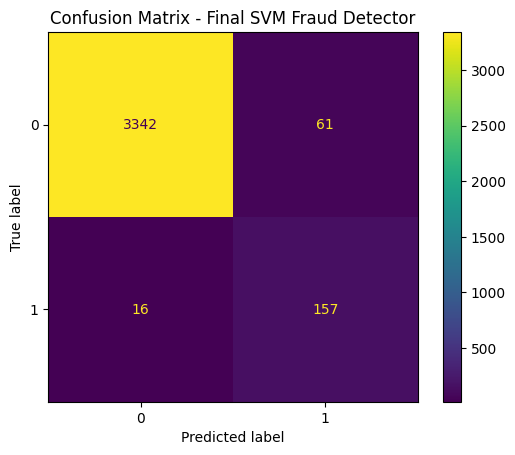

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_display = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=[0, 1]
)
plt.title("Confusion Matrix - Final SVM Fraud Detector")
plt.show()

In [ ]:
# def predict_job(text_title, text_description, text_requirements="", text_company_profile="", text_benefits="",
#                 employment_type="Unknown", required_experience="Unknown", required_education="Unknown",
#                 industry="Unknown", function="Unknown", has_company_logo=1, has_questions=0, telecommuting=0):
    
#     text_all = " ".join([
#         text_title,
#         text_description,
#         text_requirements,
#         text_company_profile,
#         text_benefits
#     ])
    
#     data = {
#         'text_all': [text_all],
#         'employment_type': [employment_type],
#         'required_experience': [required_experience],
#         'required_education': [required_education],
#         'industry': [industry],
#         'function': [function],
#         'has_company_logo': [has_company_logo],
#         'has_questions': [has_questions],
#         'telecommuting': [telecommuting]
#     }
    
#     import pandas as pd
#     X_new = pd.DataFrame(data)
    
#     pred = final_model.predict(X_new)[0]
#     prob_label = "Fraudulent" if pred == 1 else "Real"
#     print("Prediction:", prob_label)


In [ ]:
# predict_job(
#     text_title="Data Entry Clerk - Work From Home",
#     text_description="No experience needed, make $5000 per week, limited spots, apply now!!!",
#     has_company_logo=0,
#     has_questions=0,
#     telecommuting=1
# )


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(final_model, X, y, cv=5, scoring='f1_macro')
scores, scores.mean()


(array([0.88184654, 0.80476897, 0.89703311, 0.84495029, 0.87214665]),
 np.float64(0.8601491125514794))

In [ ]:
import joblib

joblib.dump(final_model, "fraud_job_model.pkl")

joblib.dump({
    "cat_cols": cat_cols,
    "num_cols": num_cols
}, "fraud_job_meta.pkl")

print("Model saved!")

Model saved!


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2
import json

# 1. Load data (or reuse df if already loaded)
df = pd.read_csv("fake_job_postings.csv")

# Basic text preprocessing: combine text
text_cols = ["title", "description", "requirements", "company_profile", "benefits"]
for c in text_cols:
    df[c] = df[c].fillna("")

df["text_all"] = (
    df["title"] + " " +
    df["description"] + " " +
    df["requirements"] + " " +
    df["company_profile"] + " " +
    df["benefits"]
)

X_text = df["text_all"]
y = df["fraudulent"]

# 2. Vectorize with n-grams (unigrams + bigrams)
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5  # ignore super-rare phrases
)
X_vec = vectorizer.fit_transform(X_text)

# 3. Use chi2 to find terms strongly associated with fraud (label 1)
chi2_scores, p_values = chi2(X_vec, y)
feature_names = vectorizer.get_feature_names_out()

# 4. Get top N fraud-associated phrases
import numpy as np

N = 50  # number of top red-flag ngrams you want
indices = np.argsort(chi2_scores)[::-1][:N]
top_terms = [feature_names[i] for i in indices]

top_terms[:30]


['aker',
 'subsea',
 'aker solutions',
 'data entry',
 'oil gas',
 'aptitude staffing',
 'signing bonus',
 'candidates encouraged',
 'global provider',
 'oil',
 'url_0fa3f7c5e23a16de16a841e368006cae916884407d90b154dfef3976483a71ae',
 'countries url_0fa3f7c5e23a16de16a841e368006cae916884407d90b154dfef3976483a71ae',
 'recovery petroleum',
 'people values',
 'bring discoveries',
 'url_0fa3f7c5e23a16de16a841e368006cae916884407d90b154dfef3976483a71ae information',
 'production maximize',
 'discoveries production',
 'people 30',
 'petroleum field',
 'provider products',
 'field employ',
 'maximize recovery',
 'cruise',
 'approximately 28',
 'employ approximately',
 'industry engineering',
 'hse',
 'refined resources',
 'leveraging career']

In [ ]:
red_flags_dict = {
    "auto_red_flags": top_terms
}

with open("red_flags.json", "w", encoding="utf-8") as f:
    json.dump(red_flags_dict, f, indent=2, ensure_ascii=False)

print("Saved red_flags.json")


Saved red_flags.json
